[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Aaxhirrr/mat-422-fall-2026/blob/AASHIR/hw2-3/HW2.3/HW2_3_joint_distributions.ipynb)

# homework 2.3: joint distributions and random samples

Aashir Javed | MAT 422 | Fall 2026

This notebook covers joint probability distributions, correlation and dependence, and random samples. I used a small probability table first so we can check the calculations by hand. The later examples show why zero correlation does not guarantee independence and what happens to sample averages as the sample size increases.

Run the cells from top to bottom. NumPy, Matplotlib, and SciPy are already available in Colab. The examples use made-up probability models and simulated data, with a fixed seed for the random samples.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, dblquad
from scipy.stats import norm

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(422)

## 2.3.1 joint probability distributions

A joint distribution describes two random variables together. For discrete variables, the joint PMF is $p(x,y)=P(X=x,Y=y)$. Every entry must be nonnegative, and all entries together must sum to 1.

In this example, $X=1$ means a rainy day and $X=0$ means a dry day. $Y=1$ means taking a car to class and $Y=0$ means taking the bus. These are the only two travel options in this model. Rows represent $X$ and columns represent $Y$.

We can add across a row to get $p_X(x)=\sum_y p(x,y)$, or down a column to get $p_Y(y)=\sum_x p(x,y)$. These are the marginal distributions. For $p_X(x)>0$, the conditional PMF is

$$p_{Y\mid X}(y\mid x)=\frac{p(x,y)}{p_X(x)}.$$

The joint CDF is $F(x,y)=P(X\leq x,Y\leq y)$. For this table, $F(0,0)$ is just the top-left entry.

In [2]:
x_values = np.array([0, 1])
y_values = np.array([0, 1])
joint = np.array([[0.40, 0.10],
                  [0.20, 0.30]])

# Rows are weather, columns are the travel choice.
px = joint.sum(axis=1)
py = joint.sum(axis=0)
car_given_rain = joint[1, 1] / px[1]
independent_table = np.outer(px, py)

print("joint PMF (rows: dry, rainy; columns: bus, car):")
print(joint)
print("total probability:", joint.sum())
print("P(X=0), P(X=1):", px)
print("P(Y=0), P(Y=1):", py)
print(f"P(car | rainy) = {car_given_rain:.4f}")
print(f"P(car) = {py[1]:.4f}")
print(f"F(0, 0) = {joint[0, 0]:.4f}")
print("X and Y are independent:", np.allclose(joint, independent_table))

joint PMF (rows: dry, rainy; columns: bus, car):
[[0.4 0.1]
 [0.2 0.3]]
total probability: 1.0
P(X=0), P(X=1): [0.5 0.5]
P(Y=0), P(Y=1): [0.6 0.4]
P(car | rainy) = 0.6000
P(car) = 0.4000
F(0, 0) = 0.4000
X and Y are independent: False


The marginals are $p_X=[0.5,0.5]$ and $p_Y=[0.6,0.4]$. Knowing it is rainy changes the chance of taking a car from 0.4 to 0.6.

Independence would require $p(x,y)=p_X(x)p_Y(y)$ for every pair. For example, the rainy/car entry is 0.30, but the product of its marginals is $0.5(0.4)=0.20$. One mismatch is enough to show dependence. The plots below compare the given table with the table we would get under independence while keeping the same marginals.

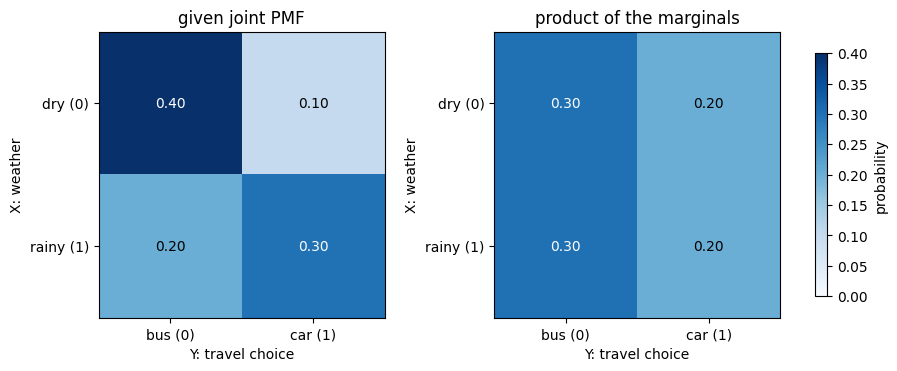

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), layout="constrained")
for ax, table, title in zip(axes, [joint, independent_table],
                            ["given joint PMF", "product of the marginals"]):
    im = ax.imshow(table, cmap="Blues", vmin=0, vmax=0.4)
    ax.set_xticks([0, 1], ["bus (0)", "car (1)"])
    ax.set_yticks([0, 1], ["dry (0)", "rainy (1)"])
    ax.set(xlabel="Y: travel choice", ylabel="X: weather", title=title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{table[i, j]:.2f}", ha="center", va="center",
                    color="white" if table[i, j] > 0.25 else "black")
fig.colorbar(im, ax=axes, label="probability", shrink=0.85)
plt.show()

### a continuous joint density

For continuous variables, probabilities are double integrals of a joint density. We can use a simple triangular region:

$$f_{U,V}(u,v)=\begin{cases}2,&0<v<u<1,\\0,&\text{otherwise}.\end{cases}$$

The triangle has area $1/2$, so its density integrates to $2(1/2)=1$. The marginal densities come from integrating out the other variable:

$$f_U(u)=\int_0^u 2\,dv=2u,\qquad f_V(v)=\int_v^1 2\,du=2(1-v),$$

for values between 0 and 1, and zero outside that interval. The joint CDF integrates over the part of the support with $U\leq u$ and $V\leq v$. In particular, $F(0.5,0.5)=0.25$.

We can also get $f_{V\mid U}(v\mid u)=f_{U,V}(u,v)/f_U(u)=1/u$ for $0<v<u$. For a fixed $u$, this is a uniform density on $(0,u)$. Its support changes with $u$, so these variables are dependent.

total joint density area = 1.0000
P(U <= 0.5, V <= 0.5) = 0.2500
P(U <= 0.5) * P(V <= 0.5) = 0.1875
conditional density area for U=0.8 = 1.0000


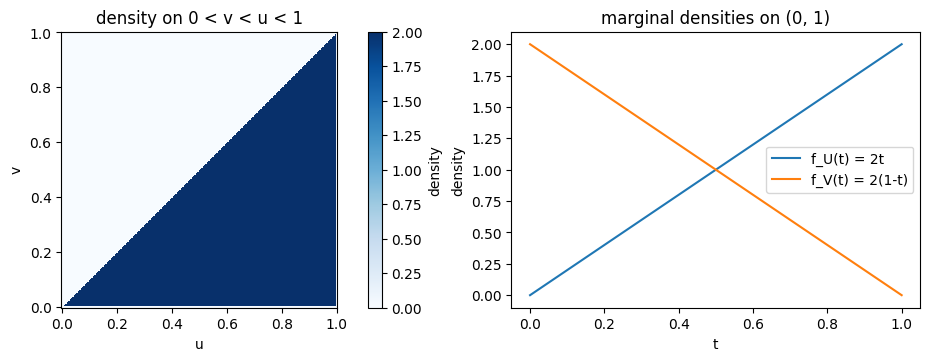

In [4]:
# dblquad passes the inner variable first: here that is v.
total_area = dblquad(lambda v, u: 2, 0, 1, lambda u: 0, lambda u: u)[0]
joint_cdf_half = dblquad(lambda v, u: 2, 0, 0.5, lambda u: 0, lambda u: u)[0]
fu_half = quad(lambda u: 2 * u, 0, 0.5)[0]
fv_half = quad(lambda v: 2 * (1 - v), 0, 0.5)[0]
conditional_area = quad(lambda v: 1 / 0.8, 0, 0.8)[0]

print(f"total joint density area = {total_area:.4f}")
print(f"P(U <= 0.5, V <= 0.5) = {joint_cdf_half:.4f}")
print(f"P(U <= 0.5) * P(V <= 0.5) = {fu_half * fv_half:.4f}")
print(f"conditional density area for U=0.8 = {conditional_area:.4f}")

grid = np.linspace(0, 1, 201)
uu, vv = np.meshgrid(grid, grid)
density = np.where((vv > 0) & (vv < uu) & (uu < 1), 2.0, 0.0)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
im = axes[0].pcolormesh(uu, vv, density, shading="auto", cmap="Blues", vmin=0, vmax=2)
axes[0].set(xlabel="u", ylabel="v", title="density on 0 < v < u < 1", aspect="equal")
fig.colorbar(im, ax=axes[0], label="density")
axes[1].plot(grid, 2 * grid, label="f_U(t) = 2t")
axes[1].plot(grid, 2 * (1 - grid), label="f_V(t) = 2(1-t)")
axes[1].set(xlabel="t", ylabel="density", title="marginal densities on (0, 1)")
axes[1].legend()
plt.show()

The total area is 1, as expected. The joint event has probability 0.25, while multiplying the marginal probabilities gives $0.25(0.75)=0.1875$. That confirms dependence in another way. The density height of 2 is fine because it is the area that represents probability. The boundary lines have zero area, so their density values do not affect these probabilities.

## 2.3.2 correlation and dependence

Covariance measures how two variables vary together:

$$\operatorname{Cov}(X,Y)=E[XY]-E[X]E[Y].$$

When both variances are positive, correlation rescales covariance to a number between -1 and 1:

$$\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y}.$$

Positive correlation means larger values tend to occur together; negative correlation means larger values of one tend to occur with smaller values of the other. This measures linear association and does not by itself establish causation. We can calculate the population values directly from the weather/travel PMF without drawing a sample.

In [5]:
mean_x = np.sum(x_values * px)
mean_y = np.sum(y_values * py)
var_x = np.sum((x_values - mean_x)**2 * px)
var_y = np.sum((y_values - mean_y)**2 * py)
mean_xy = np.sum(x_values[:, None] * y_values[None, :] * joint)
cov_xy = mean_xy - mean_x * mean_y
corr_xy = cov_xy / np.sqrt(var_x * var_y)

print(f"E[X] = {mean_x:.4f}, E[Y] = {mean_y:.4f}, E[XY] = {mean_xy:.4f}")
print(f"Var(X) = {var_x:.4f}, Var(Y) = {var_y:.4f}")
print(f"covariance = {cov_xy:.4f}")
print(f"correlation = {corr_xy:.4f}")
print(f"correlation of X and 1-Y = {-corr_xy:.4f}")

E[X] = 0.5000, E[Y] = 0.4000, E[XY] = 0.3000
Var(X) = 0.2500, Var(Y) = 0.2400
covariance = 0.1000
correlation = 0.4082
correlation of X and 1-Y = -0.4082


The covariance is 0.1 and the correlation is about 0.4082. In this model, rainy days are associated with taking a car. Replacing $Y$ with $1-Y$ changes the indicator to taking the bus, so the correlation changes sign. These are properties of the model we chose, not findings from real travel data.

### zero correlation does not guarantee independence

If two variables are independent and have finite second moments, their covariance is zero. The reverse does not always work. For a small counterexample, take $A$ equally likely to be -1, 0, or 1, and set $B=A^2$.

Then $E[A]=0$, $E[B]=2/3$, and $E[AB]=(-1+0+1)/3=0$. That gives zero covariance and zero correlation. But if we know $A=0$, then we know $B=0$ for sure. We can check that against the unconditional probability $P(B=0)=1/3$.

covariance = 0.0000; correlation = 0.0000
P(B=0) = 0.3333
P(B=0 | A=0) = 1.0000


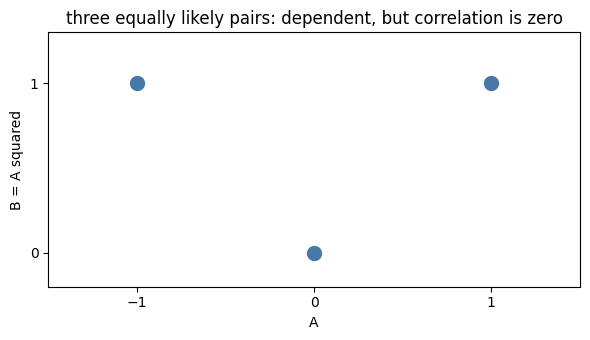

In [6]:
a = np.array([-1.0, 0.0, 1.0])
b = a**2
weights = np.full(3, 1 / 3)
mean_a = np.sum(a * weights)
mean_b = np.sum(b * weights)
var_a = np.sum((a - mean_a)**2 * weights)
var_b = np.sum((b - mean_b)**2 * weights)
cov_ab = np.sum((a - mean_a) * (b - mean_b) * weights)
corr_ab = cov_ab / np.sqrt(var_a * var_b)
p_b_zero = weights[b == 0].sum()
p_b_zero_given_a_zero = weights[(b == 0) & (a == 0)].sum() / weights[a == 0].sum()

print(f"covariance = {cov_ab:.4f}; correlation = {corr_ab:.4f}")
print(f"P(B=0) = {p_b_zero:.4f}")
print(f"P(B=0 | A=0) = {p_b_zero_given_a_zero:.4f}")

plt.figure(figsize=(6, 3.5))
plt.scatter(a, b, s=100, color="#4878a8")
plt.xticks(a)
plt.yticks([0, 1])
plt.xlim(-1.5, 1.5)
plt.ylim(-0.2, 1.3)
plt.xlabel("A")
plt.ylabel("B = A squared")
plt.title("three equally likely pairs: dependent, but correlation is zero")
plt.tight_layout()
plt.show()

The correlation is exactly zero here, not just close to zero because of sampling noise. Still, the conditional probability is 1 instead of $1/3$, so the variables are dependent. The plot makes the issue easier to see: both -1 and 1 give the same value of $B$, and a straight-line trend misses that relationship.

## 2.3.3 random samples

A random sample $T_1,\ldots,T_n$ consists of independent, identically distributed (i.i.d.) random variables. Each observation has the same population distribution, and the joint density factors as $\prod_{i=1}^n f_T(t_i)$.

For this example, we can model a waiting time in minutes with an exponential distribution of rate $\lambda=0.5$. Its density is $f_T(t)=0.5e^{-0.5t}$ for $t\geq 0$, its mean is $\mu=2$, and its variance is $\sigma^2=4$. This is a separate waiting-time model from the uniform example in HW 2.2.

The sample mean and sample variance are

$$\bar T=\frac{1}{n}\sum_{i=1}^n T_i,\qquad S^2=\frac{1}{n-1}\sum_{i=1}^n(T_i-\bar T)^2.$$

We use `ddof=1` for the $n-1$ denominator. It makes $S^2$ an unbiased estimator of the population variance under these assumptions; it does not make every sample variance equal to 4.

In [7]:
population_mean = 2.0
population_variance = 4.0
sample = rng.exponential(scale=population_mean, size=1000)

print("first 8 simulated waits:", sample[:8])
print("   n    sample mean    sample variance")
for n in [10, 100, 1000]:
    current = sample[:n]
    print(f"{n:4d}       {current.mean():.4f}             {current.var(ddof=1):.4f}")
print("population mean = 2; population variance = 4")

first 8 simulated waits: [2.484  2.4197 1.6567 2.3976 0.6924 1.3781 0.1379 6.9429]
   n    sample mean    sample variance
  10       2.4432             3.5021
 100       2.0735             3.8818
1000       2.0439             4.2090
population mean = 2; population variance = 4


The rows above use longer prefixes of the same sample, so they are not three independent experiments. Their means and variances will not be exactly 2 and 4. The fixed seed keeps this particular simulation repeatable.

The law of large numbers says the sample mean converges to the population mean as the sample size grows, under these i.i.d. assumptions with a finite mean. It does not say each additional observation must move the average closer. We can see those small moves in the running average below.

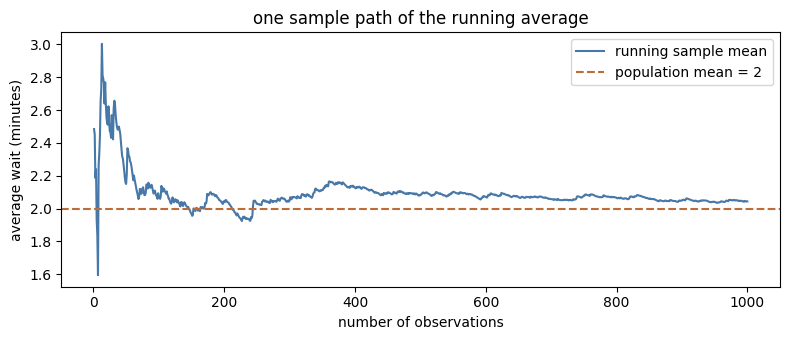

In [8]:
sample_sizes = np.arange(1, len(sample) + 1)
running_mean = np.cumsum(sample) / sample_sizes

plt.figure(figsize=(8, 3.5))
plt.plot(sample_sizes, running_mean, color="#4878a8", label="running sample mean")
plt.axhline(population_mean, color="#bd6b37", linestyle="--", label="population mean = 2")
plt.xlabel("number of observations")
plt.ylabel("average wait (minutes)")
plt.title("one sample path of the running average")
plt.legend()
plt.tight_layout()
plt.show()

### repeated samples and the central limit theorem

One sample path cannot show the whole sampling distribution. We can repeat the experiment 10,000 times for each sample size and keep the mean from each repetition. For i.i.d. observations with finite variance,

$$E[\bar T]=\mu,\qquad \operatorname{Var}(\bar T)=\frac{\sigma^2}{n},\qquad \operatorname{SE}(\bar T)=\frac{\sigma}{\sqrt n}.$$

The central limit theorem says $\sqrt n(\bar T-\mu)/\sigma$ approaches a standard normal distribution as $n$ grows. So the sample mean is approximately normal for large $n$, even though the individual exponential waits are skewed. There is no universal sample size that makes the approximation exact.

In [9]:
repetitions = 10000
sizes = [1, 5, 30]
sample_means = {}

print("   n    mean of means    observed variance    theoretical variance")
for n in sizes:
    # Each row is a new sample; averaging across columns gives one mean per row.
    samples = rng.exponential(scale=population_mean, size=(repetitions, n))
    means = samples.mean(axis=1)
    sample_means[n] = means
    print(f"{n:4d}          {means.mean():.4f}               {means.var(ddof=1):.4f}                  {population_variance / n:.4f}")

   n    mean of means    observed variance    theoretical variance
   1          1.9907               3.8948                  4.0000
   5          1.9872               0.7823                  0.8000
  30          1.9967               0.1324                  0.1333


The theoretical variances are 4, 0.8, and about 0.1333. Increasing $n$ from 1 to 30 divides the variance of the sample mean by 30, while its expected value stays at 2. The observed variances should be nearby, with some simulation error.

The plots use density-scaled histograms so they can be compared with the normal density having mean 2 and standard deviation $2/\sqrt n$. At $n=1$, the normal curve is a poor fit. It becomes more useful as the distribution of sample means becomes less skewed. The same horizontal scale is used in all three panels.

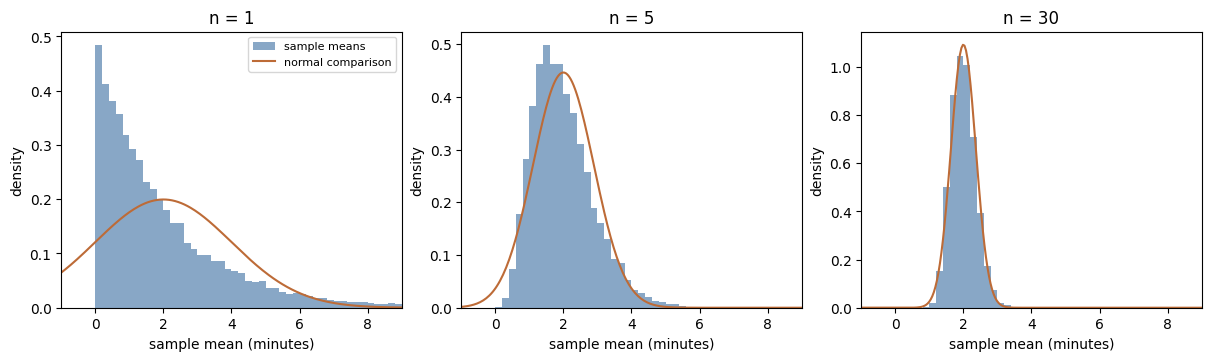

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, layout="constrained")
curve_x = np.linspace(-5, 22, 600)
largest_mean = max(means.max() for means in sample_means.values())
bins = np.arange(-5, np.ceil(largest_mean) + 1, 0.2)
for ax, n in zip(axes, sizes):
    means = sample_means[n]
    standard_error = np.sqrt(population_variance / n)
    ax.hist(means, bins=bins, density=True, color="#4878a8", alpha=0.65, label="sample means")
    ax.plot(curve_x, norm.pdf(curve_x, population_mean, standard_error),
            color="#bd6b37", label="normal comparison")
    ax.set(title=f"n = {n}", xlabel="sample mean (minutes)", ylabel="density", xlim=(-1, 9))
axes[0].legend(fontsize=8)
plt.show()

The histograms become more concentrated around 2 as $n$ increases. The normal comparison is still only an approximation, and it assigns some probability to negative values even though an average of waiting times cannot be negative. The displayed range is -1 to 9; a few larger simulated means are outside the visible range, but the histogram includes them when calculating density.

## quick checks

These checks compare the exact examples with their hand-calculated values. The last check allows 10% relative error for the simulated sampling variances because a simulation is not an exact identity. Passing these checks supports the calculations here, not a proof of the limit theorems.

In [11]:
checks = {
    "joint PMF is valid": np.all(joint >= 0) and np.isclose(joint.sum(), 1),
    "marginals match the table": np.allclose(px, [0.5, 0.5]) and np.allclose(py, [0.6, 0.4]),
    "conditional car probability is 0.6": np.isclose(car_given_rain, 0.6),
    "weather and travel are dependent": not np.allclose(joint, independent_table),
    "continuous joint density integrates to 1": np.isclose(total_area, 1),
    "continuous joint CDF is 0.25": np.isclose(joint_cdf_half, 0.25),
    "conditional density integrates to 1": np.isclose(conditional_area, 1),
    "covariance and correlation match": np.allclose([cov_xy, corr_xy], [0.1, 1 / np.sqrt(6)]),
    "counterexample has zero correlation": np.isclose(corr_ab, 0),
    "counterexample is still dependent": not np.isclose(p_b_zero, p_b_zero_given_a_zero),
    "running mean ends at the full sample mean": np.isclose(running_mean[-1], sample.mean()),
    "sampling variances are near 4/n": all(np.isclose(sample_means[n].var(ddof=1), 4 / n, rtol=0.1) for n in sizes),
}
for label, passed in checks.items():
    print(f"{label}: {bool(passed)}")
assert all(checks.values()), "one of the checks needs another look"

joint PMF is valid: True
marginals match the table: True
conditional car probability is 0.6: True
weather and travel are dependent: True
continuous joint density integrates to 1: True
continuous joint CDF is 0.25: True
conditional density integrates to 1: True
covariance and correlation match: True
counterexample has zero correlation: True
counterexample is still dependent: True
running mean ends at the full sample mean: True
sampling variances are near 4/n: True


## what I took from this

The joint table gives more information than either marginal by itself. We can keep the same weather and travel totals while changing how often they happen together. That is why comparing the joint PMF with the product of its marginals is useful.

The $B=A^2$ example is the part I would be careful about when interpreting correlation. A value of zero can miss a relationship even when one variable completely determines the other. For the samples, increasing the sample size reduces the spread of the average, but it does not remove variation from the individual waiting times.

Before submitting, I need to run all cells, review the explanations and outputs, and check that the Open in Colab link works from GitHub.

## references and AI use

- MAT 422, section 2.3: joint probability distributions, correlation and dependence, and random samples.
- [Section 2.3 homework guidance](https://github.com/DynamicLLM/MAT422/blob/main/Skills/Student-Home-Work-Skills-Pack/mat422-section-2-3-joint-distributions-sampling/references/section-2-3-guidance.md).
- AI use note: I had help from Codex in refining the code (not completely writing it), refining the latex of the report, and pushing it to GitHub. Other than that, the intial psuedocode/boilerplates, logic, and the report is still drafted by me. I ran every cell and reviewed the math and explanations before submitting.